# Week 9 / 10 - Regression Analysis

**Goal:** Apply regression models to predict a continuous target, starting with a Linear Regression baseline, then increasing model flexibility using Polynomial Regression, and finally controlling overfitting using Ridge Regularization. Use validation results to choose the best model and explain the trade-off between underfitting and overfitting.

## A. Setup + Data Preparation

In [75]:
import os
import sys
import platform
import json
import math
import random

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('Pandas:', pd.__version__)

Python: 3.13.7
Platform: Linux-6.17.0-22-generic-x86_64-with-glibc2.42
Pandas: 3.0.1


In [76]:
from pathlib import Path

PROJECT_ROOT = Path.cwd() / "energy_consumption"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
CONFIGS = PROJECT_ROOT / "configs"

for p in [DATA_RAW, DATA_INTERIM, DATA_PROCESSED, REPORTS, CONFIGS]:
    p.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

SEED = 42

In [77]:
data_raw = pd.read_csv(DATA_RAW / "energy_data_raw.csv")
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   str    
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   str    
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 54.8 KB


In [78]:
data_raw.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [79]:
data = data_raw.copy()

data = data.rename(columns = {
    "Building Type": "building_type",
    "Square Footage": "square_footage",
    "Number of Occupants": "number_of_occupants",
    "Appliances Used": "appliances_used",
    "Average Temperature": "average_temperature",
    "Day of Week": "day_of_week",
    "Energy Consumption": "energy_consumption"
})

data["building_type"] = data["building_type"].str.lower().astype("category")
data["day_of_week"] = data["day_of_week"].str.lower().astype("category")

data.to_csv(DATA_PROCESSED / "energy_data_processed.csv", index=False)

print(data.dtypes)

building_type          category
square_footage            int64
number_of_occupants       int64
appliances_used           int64
average_temperature     float64
day_of_week            category
energy_consumption      float64
dtype: object


In [80]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

y = data["energy_consumption"]

X = data.drop(columns=["energy_consumption"])
prep = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(drop='first'), ['building_type', 'day_of_week']),
    ('num', StandardScaler(), ['square_footage', 'number_of_occupants', 'appliances_used', 'average_temperature'])
])
X = prep.fit_transform(X)

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, random_state = SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = SEED)

print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (700, 7) (700,)
Validation set: (150, 7) (150,)
Test set: (150, 7) (150,)


**Chosen regression evaluation criteria:**
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² score

**Why is regression the correct supervised learning setting for this problem?**

Regression is the correct supervised learning setting because the target variable is a continuous numerical value.

## B. Linear Regression Baseline

### B1. Initial Model

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

lin_reg_results = {
    "intercept": lin_reg_model.intercept_,
    "coefficients": lin_reg_model.coef_,
    "train_mse": mean_squared_error(y_train, lin_reg_model.predict(X_train)),
    "val_mse": mean_squared_error(y_val, lin_reg_model.predict(X_val)),
    "val_rmse": np.sqrt(mean_squared_error(y_val, lin_reg_model.predict(X_val))),
    "val_mae": mean_absolute_error(y_val, lin_reg_model.predict(X_val)),
    "val_r2": r2_score(y_val, lin_reg_model.predict(X_val))
}

print("---------- Linear Regression Results ----------")
for metric, value in lin_reg_results.items():
    print(f"{metric}: {value}")

---------- Linear Regression Results ----------
intercept: 4205.903085330073
coefficients: [ 500.00042716 -500.00003593  -50.00155034  714.36997865  290.47434894
  281.96256361  -35.68268186]
train_mse: 0.00018503058723767286
val_mse: 0.00018609154446878987
val_rmse: 0.013641537467191513
val_mae: 0.011735886597431697
val_r2: 0.999999999754069


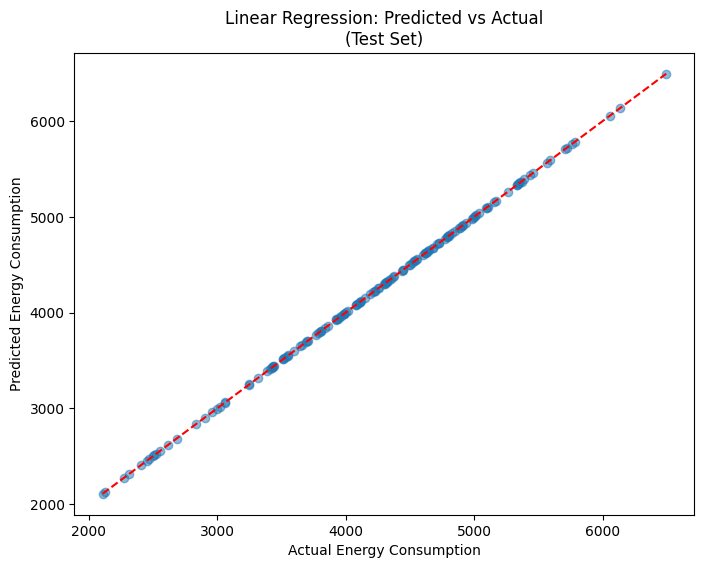

In [83]:
y_pred_test = lin_reg_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)

# Reference line for perfect predictions
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Linear Regression: Predicted vs Actual\n(Test Set)")
plt.show()

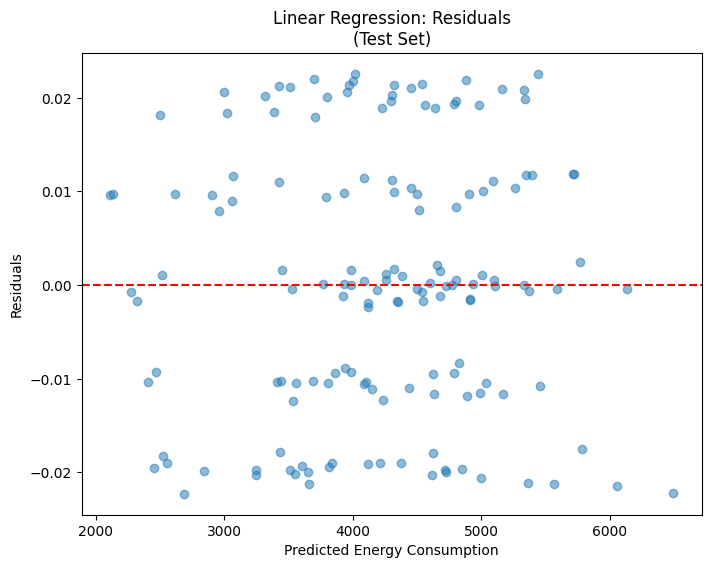

In [84]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')

plt.xlabel("Predicted Energy Consumption")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residuals\n(Test Set)")
plt.show()

### B2. Interpreting the Baseline

In [85]:
feature_names = prep.get_feature_names_out()
coefficients = lin_reg_model.coef_

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
})

coef_table = coef_table.sort_values(
    by="absolute_coefficient",
    ascending=False
)

coef_table

,feature,coefficient,absolute_coefficient
3,num__square_footage,714.369979,714.369979
0,cat__building_type_industrial,500.000427,500.000427
1,cat__building_type_residential,-500.000036,500.000036
4,num__number_of_occupants,290.474349,290.474349
5,num__appliances_used,281.962564,281.962564
2,cat__day_of_week_weekend,-50.001550,50.001550
6,num__average_temperature,-35.682682,35.682682


**Identify which features appear to have the strongest influence on the prediction.**

It looks like the features that influence the prediction the most are the square footage of the building, and whether it is an industrial or a residential building.

**Does the linear model seem to fit the data well? What patterns do you notice in the residuals or prediction errors?**

The linear model seems to fit the data very well.<br/>
The residuals are centered around 0 and are very small, mostly between -0.02 and 0.02.

## C. Polynomial Regression

### C1. Increasing Flexibility

In [86]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

def report_poly_reg(poly_degree = 2):
    poly_features = PolynomialFeatures(degree=poly_degree)
    model = LinearRegression()
    
    poly_reg_pipeline = Pipeline([
        ('poly_features', poly_features),
        ('linear_model', model)
    ])

    poly_reg_pipeline.fit(X_train, y_train)
    y_pred_train = poly_reg_pipeline.predict(X_train)
    y_pred_val = poly_reg_pipeline.predict(X_val)

    poly_reg_results = {
        "poly_degree": poly_degree,
        "train_mse": mean_squared_error(y_train, y_pred_train),
        "val_mse": mean_squared_error(y_val, y_pred_val),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_pred_val)),
        "val_mae": mean_absolute_error(y_val, y_pred_val),
        "val_r2": r2_score(y_val, y_pred_val)
    }
    
    return poly_reg_results

all_poly_results = []
for poly_degree in [2, 3, 4]:
    results = report_poly_reg(poly_degree)
    all_poly_results.append(results)

poly_table = pd.DataFrame(all_poly_results)
poly_table


,poly_degree,train_mse,val_mse,val_rmse,val_mae,val_r2
0,2,0.000180,0.000191,0.013836,0.011871,1.0
1,3,0.000166,0.000220,0.014827,0.012800,1.0
2,4,0.000138,0.000305,0.017468,0.014233,1.0


### C2. Model Selection

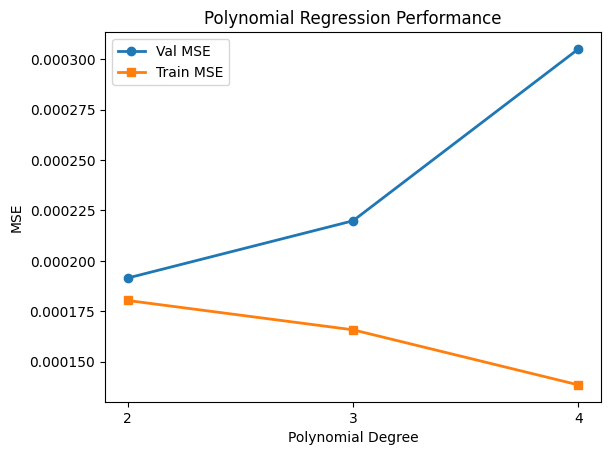

In [87]:
# connect the dots
poly_degrees = [result["poly_degree"] for result in all_poly_results]
train_mses = [result["train_mse"] for result in all_poly_results]
val_mses = [result["val_mse"] for result in all_poly_results]

plt.plot(poly_degrees, val_mses, marker='o', label='Val MSE', linewidth=2)
plt.plot(poly_degrees, train_mses, marker='s', label='Train MSE', linewidth=2)

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Polynomial Regression Performance")
plt.legend()
plt.xticks(poly_degrees)
plt.show()

The best polynomial degree value based on validation performance is 2.

**What happened to the training error as model flexibility increased? What happened to the validation error?**

As the model's flexibility increased, the training error decreased a little but the validation error sharply increased.
This suggests overfitting.

**Which degrees appear to underfit, and which appear to overfit?**

None of the tested degrees seem to underfit.<br/>
Choosing 3 degrees seems to overfit a little, while choosing 4 seems to produce a big uptick in overfitting.

### C3. Visualization

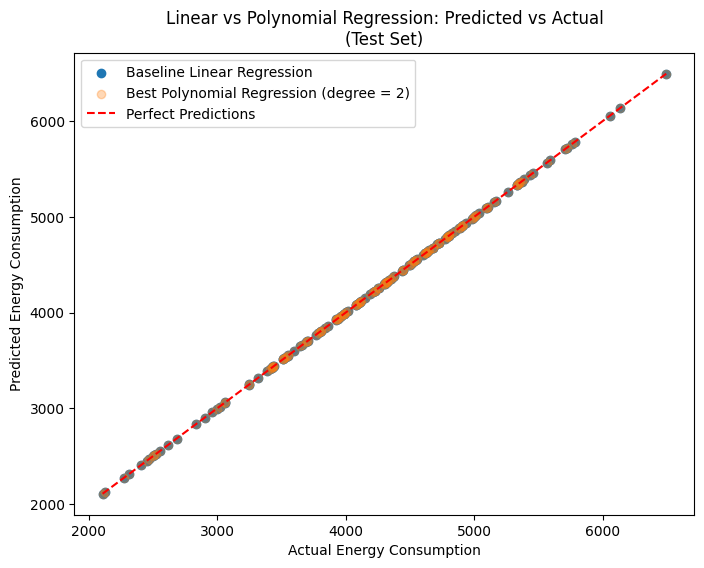

In [88]:
y_pred_test_lin = lin_reg_model.predict(X_test)

poly_reg_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree = 2)),
    ('linear_model', LinearRegression())
])
poly_reg_model.fit(X_train, y_train)
y_pred_test_poly = poly_reg_model.predict(X_test)

plt.figure(figsize = (8, 6))
plt.scatter(y_test, y_pred_test_lin, label='Baseline Linear Regression')
plt.scatter(y_test, y_pred_test_poly, alpha=0.3, label='Best Polynomial Regression (degree = 2)')

# Reference line for perfect predictions
min_val = min(y_test.min(), y_pred_test_lin.min(), y_pred_test_poly.min())
max_val = max(y_test.max(), y_pred_test_lin.max(), y_pred_test_poly.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Predictions')

plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Linear vs Polynomial Regression: Predicted vs Actual\n(Test Set)")
plt.legend()
plt.show()

## D. Ridge Regression

### D1. Regularization Setup

In [89]:
from sklearn.linear_model import Ridge

ridge_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge_reg', Ridge(alpha = 1.0))
])
ridge_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


**Explain your choice of features.**

I chose to use the original features because the data already shows a very linear trend, so adding more polynomial features would likely make the model unnecessarily complex.

### D2. Tuning Regularization Strength

In [90]:
def report_ridge_reg(alpha = 1.0):
    ridge_reg_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge_reg', Ridge(alpha = alpha))
    ])
    ridge_reg_pipeline.fit(X_train, y_train)

    ridge_reg_results = {
        "alpha": alpha,
        "train_mse": mean_squared_error(y_train, ridge_reg_pipeline.predict(X_train)),
        "val_mse": mean_squared_error(y_val, ridge_reg_pipeline.predict(X_val)),
        "val_rmse": np.sqrt(mean_squared_error(y_val, ridge_reg_pipeline.predict(X_val))),
        "val_mae": mean_absolute_error(y_val, ridge_reg_pipeline.predict(X_val)),
        "val_r2": r2_score(y_val, ridge_reg_pipeline.predict(X_val))
    }
    
    return ridge_reg_results

all_ridge_results = []
for alpha in [0.001, 0.01, 0.1]:
    results = report_ridge_reg(alpha)
    all_ridge_results.append(results)

ridge_table = pd.DataFrame(all_ridge_results)
ridge_table

,alpha,train_mse,val_mse,val_rmse,val_mae,val_r2
0,0.001,0.000187,0.000188,0.013722,0.011807,1.0
1,0.010,0.000333,0.000322,0.017951,0.014668,1.0
2,0.100,0.015008,0.012948,0.113790,0.095773,1.0


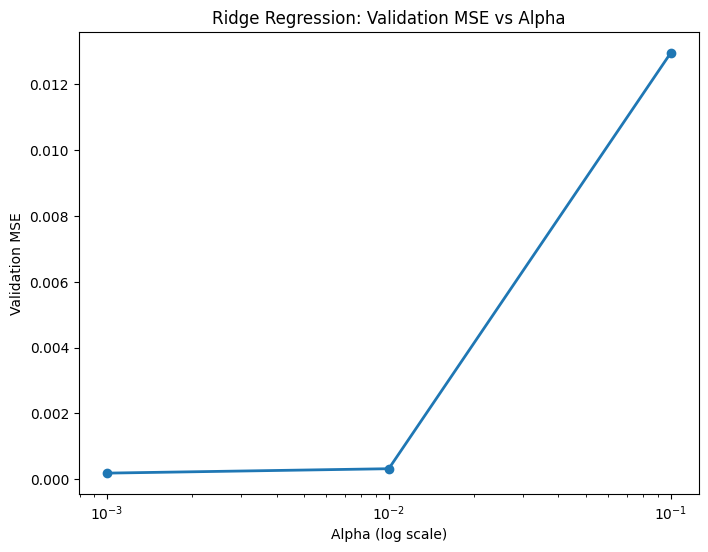

In [91]:
# Create a plot showing validation performance versus alpha.
plt.figure(figsize = (8, 6))
plt.plot(
    ridge_table["alpha"], 
    ridge_table["val_mse"], 
    marker = 'o', 
    label = 'Validation MSE', 
    linewidth = 2
)

plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Validation MSE")
plt.title("Ridge Regression: Validation MSE vs Alpha")
plt.show()

**Select the best Ridge model based on validation performance.**

The best Ridge model based on validation performance in this case is the one using `alpha = 0.001`.

### D3. Effect of Regularization

In [92]:
poly_feature_names = poly_reg_model.named_steps['poly_features'].get_feature_names_out()
poly_coefficients = poly_reg_model.named_steps['linear_model'].coef_
poly_coef_table = pd.DataFrame({
    "feature": poly_feature_names,
    "coefficient": poly_coefficients,
    "absolute_coefficient": np.abs(poly_coefficients)
}).sort_values("absolute_coefficient", ascending=False)

print("---------- Polynomial Coefficients ----------")
poly_coef_table

---------- Polynomial Coefficients ----------


,feature,coefficient,absolute_coefficient
4,x3,7.143687e+02,7.143687e+02
5,x4,2.904740e+02,2.904740e+02
6,x5,2.819617e+02,2.819617e+02
8,x0^2,2.500008e+02,2.500008e+02
1,x0,2.500008e+02,2.500008e+02
15,x1^2,-2.500002e+02,2.500002e+02
2,x1,-2.500002e+02,2.500002e+02
7,x6,-3.568296e+01,3.568296e+01
3,x2,-2.500059e+01,2.500059e+01
21,x2^2,-2.500059e+01,2.500059e+01


In [93]:
ridge_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge_reg', Ridge(alpha = 0.001))
])
ridge_reg_model.fit(X_train, y_train)

ridge_coefficients = ridge_reg_model.named_steps['ridge_reg'].coef_
ridge_coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": ridge_coefficients,
    "absolute_coefficient": np.abs(ridge_coefficients)
}).sort_values("absolute_coefficient", ascending=False)

print("---------- Ridge Coefficients ----------")
ridge_coef_table

---------- Ridge Coefficients ----------


,feature,coefficient,absolute_coefficient
3,num__square_footage,720.377038,720.377038
4,num__number_of_occupants,295.508674,295.508674
5,num__appliances_used,281.930999,281.930999
1,cat__building_type_residential,-238.258752,238.258752
0,cat__building_type_industrial,233.512505,233.512505
6,num__average_temperature,-35.866980,35.866980
2,cat__day_of_week_weekend,-24.988377,24.988377


**Compare the coefficients of the best Polynomial Regression model and the best Ridge Regression model.**

The coefficients can't be compared directly feature-by-feature because the models were trained on different feature spaces, since I chose to use the original input features for the Ridge model.

**How did regularization affect the coefficient sizes and the generalization performance?**

Ridge regularization reduced the magnitude of several coefficients, especially the categorical building type coefficients and the weekend coefficient, making the model less dependent on individual categorical features. The numerical feature coefficients remained very similar, suggesting that their effects were stable.<br/>
It achieved a very similar generalization performance to that of Linear Regression, since the dataset already appears to follow a strong linear trend.

## E. Final Comparison of Regression Models

### E1. Comparison Table

In [94]:
def report_test_results(model):
    y_pred_test = model.predict(X_test)
    test_results = {
        "test_mse": mean_squared_error(y_test, y_pred_test),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "test_mae": mean_absolute_error(y_test, y_pred_test),
        "test_r2": r2_score(y_test, y_pred_test)
    }
    return test_results

lin_test_results = report_test_results(lin_reg_model)
poly_test_results = report_test_results(poly_reg_model)
ridge_test_results = report_test_results(ridge_reg_model)

print("---------- Test Set Performance ----------")

comparison_table = pd.DataFrame([
    {
        "Model Name": "Linear Regression",
        "Main Parameter Used": "N/A",
        "Training MSE": lin_test_results["test_mse"],
        "Validation MSE": lin_test_results["test_rmse"],
        "Validation RMSE": lin_test_results["test_rmse"],
        "Validation MAE": lin_test_results["test_mae"],
        "Validation R²": lin_test_results["test_r2"]
    },
    {
        "Model Name": "Polynomial Regression",
        "Main Parameter Used": f"Degree = {poly_reg_model.named_steps['poly_features'].degree}",
        "Training MSE": poly_test_results["test_mse"],
        "Validation MSE": poly_test_results["test_rmse"],
        "Validation RMSE": poly_test_results["test_rmse"],
        "Validation MAE": poly_test_results["test_mae"],
        "Validation R²": poly_test_results["test_r2"]
    },
    {
        "Model Name": "Ridge Regression",
        "Main Parameter Used": f"Alpha = {ridge_reg_model.named_steps['ridge_reg'].alpha}",
        "Training MSE": ridge_test_results["test_mse"],
        "Validation MSE": ridge_test_results["test_rmse"],
        "Validation RMSE": ridge_test_results["test_rmse"],
        "Validation MAE": ridge_test_results["test_mae"],
        "Validation R²": ridge_test_results["test_r2"]
    }
])
comparison_table

---------- Test Set Performance ----------


,Model Name,Main Parameter Used,Training MSE,Validation MSE,Validation RMSE,Validation MAE,Validation R²
0,Linear Regression,N/A,0.000195,0.013981,0.013981,0.011600,1.0
1,Polynomial Regression,Degree = 2,0.000197,0.014018,0.014018,0.011768,1.0
2,Ridge Regression,Alpha = 0.001,0.000197,0.014047,0.014047,0.011713,1.0


**Identify which model performed best under each evaluation criterion.**

Linear Regression performed the best overall, having the lowest value in all errors, except R², where all models tied. Since the differences between models are extremely small, the simpler Linear Regression model is the preferred choice because it not only performs better, but is also easier to interpret.

### E2. Analysis of Results

**Did the most flexible model always perform best on validation or test data?**

The most flexible model did not perform best on the validation data. The Linear Regression model for example still had slightly lower validation error. This suggests that extra flexibility was unnecessary for this dataset, because the data already followed along a very strong linear trend.

**How did regularization help with overfitting?**

Regularization helped by shrinking the model coefficients towards 0, especially for features that had very large coefficient values. This reduces the chance that the model depends too strongly on individual features or noise in the training data.<br/>
In this specific case, it did not dramatically improve validation performance, but it made the model more stable.

**Which model would you trust most for new unseen data, and why?**

I would trust the Linear Regression model most. It had the best validation performance while also being the simplest and more interpretable model.<br/>
Since all models performed almost perfectly, the simplest model is preferable because it is less likely to overfit.